<a href="https://colab.research.google.com/github/Bachbean/Predicting-the-Unpredictable/blob/main/scripts/CM1_ami.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Number of rows: 10000
Column 1 shape: (10000,)
Column 2 shape: (10000,)
Column 3 shape: (10000,)
Column 4 shape: (10000,)
Column 1: first AMI minimum = 112
Column 2: first AMI minimum = 69
Column 3: first AMI minimum = 67
Column 4: first AMI minimum = 78


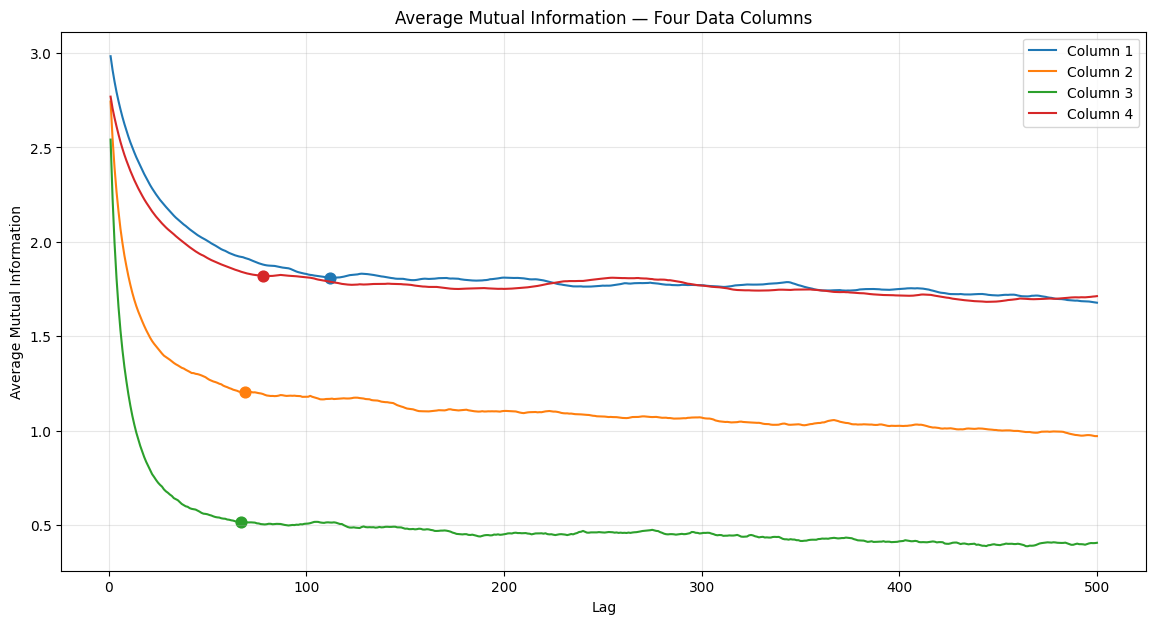


Tau values:
[np.int64(112), np.int64(69), np.int64(67), np.int64(78)]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import requests
from io import StringIO


# ============================================================
# 1. LOAD CSV FROM GITHUB
# ============================================================

url = "https://raw.githubusercontent.com/Bachbean/Predicting-the-Unpredictable/refs/heads/main/scripts/CM1_all_vars_30s.csv"

response = requests.get(url)
response.raise_for_status()

raw_text = response.text


# ============================================================
# 2. READ CSV AND IGNORE FIRST LINE
# ============================================================

data_all = np.loadtxt(
    StringIO(raw_text),
    delimiter=",",
    dtype=np.float64,
    skiprows=1
)

data = data_all[:10000]

if data.ndim != 2 or data.shape[1] != 4:
    raise ValueError(
        "Expected exactly four comma-separated numerical columns."
    )


# ============================================================
# 3. SPLIT FOUR COLUMNS INTO FOUR ARRAYS
# ============================================================

data1 = data[:, 0]
data2 = data[:, 1]
data3 = data[:, 2]
data4 = data[:, 3]

all_data = [
    data1,
    data2,
    data3,
    data4
]

print("Number of rows:", len(data))
print("Column 1 shape:", data1.shape)
print("Column 2 shape:", data2.shape)
print("Column 3 shape:", data3.shape)
print("Column 4 shape:", data4.shape)


# ============================================================
# 4. SETTINGS
# ============================================================

max_lag = 500

num_bins = 32


# ============================================================
# 5. MUTUAL INFORMATION FUNCTION
# ============================================================

def mutual_information(x, y, bins):

    joint_hist, _, _ = np.histogram2d(
        x,
        y,
        bins=bins
    )

    joint_prob = (
        joint_hist
        /
        np.sum(joint_hist)
    )

    prob_x = np.sum(
        joint_prob,
        axis=1
    )

    prob_y = np.sum(
        joint_prob,
        axis=0
    )

    expected = (
        prob_x[:, None]
        *
        prob_y[None, :]
    )

    valid = (
        (joint_prob > 0)
        &
        (expected > 0)
    )

    mi = np.sum(
        joint_prob[valid]
        *
        np.log(
            joint_prob[valid]
            /
            expected[valid]
        )
    )

    return mi


# ============================================================
# 6. CALCULATE AMI FOR ALL FOUR COLUMNS
# ============================================================

lags = np.arange(
    1,
    max_lag + 1
)

ami_by_column = []

tau_by_column = []


for column_number, series in enumerate(
    all_data,
    start=1
):

    ami_values = []

    for lag in lags:

        x = series[:-lag]

        y = series[lag:]

        mi = mutual_information(
            x,
            y,
            bins=num_bins
        )

        ami_values.append(mi)


    ami_values = np.asarray(
        ami_values
    )

    ami_by_column.append(
        ami_values
    )


    # --------------------------------------------------------
    # FIND FIRST LOCAL MINIMUM
    # --------------------------------------------------------

    first_minimum = None

    for i in range(
        1,
        len(ami_values) - 1
    ):

        if (
            ami_values[i]
            <
            ami_values[i - 1]
            and
            ami_values[i]
            <
            ami_values[i + 1]
        ):

            first_minimum = lags[i]

            break


    tau_by_column.append(
        first_minimum
    )


    print(
        f"Column {column_number}: "
        f"first AMI minimum = {first_minimum}"
    )


# ============================================================
# 7. PLOT ALL FOUR AMI CURVES
# ============================================================

plt.figure(
    figsize=(14, 7)
)


for column in range(4):

    values = ami_by_column[column]

    plt.plot(
        lags,
        values,
        label=f"Column {column + 1}"
    )

    tau = tau_by_column[column]

    if tau is not None:

        plt.scatter(
            tau,
            values[tau - 1],
            s=60
        )


plt.xlabel("Lag")
plt.ylabel("Average Mutual Information")

plt.title(
    "Average Mutual Information — Four Data Columns"
)

plt.grid(alpha=0.3)

plt.legend()

plt.show()